# 6CS012 - Worksheet 4: Exercise
## Building a Fully Connected Network (FCN) for Devnagari Digit Classification

**Student:** Amresh (ID: 2418108)  
**Module:** 6CS012 - Artificial Intelligence and Machine Learning  
**Module Leader:** Siman Giri  

---

### Objective
Build and train a Fully Connected Network (FCN) to classify Devnagari handwritten digits using TensorFlow and Keras. The dataset is manually loaded using PIL, and the model uses three hidden layers with sigmoid activation.


In [10]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Task 1: Data Preparation

Loading the Devnagari digits dataset using PIL, converting images to NumPy arrays, normalizing to [0, 1], and extracting labels from folder names.


In [11]:
# Import required libraries
import os
import numpy as np
import tensorflow as tf
from tensorflow.keras.utils import to_categorical
import matplotlib.pyplot as plt
from PIL import Image

print(f"TensorFlow version: {tf.__version__}")
print(f"Keras version: {tf.keras.__version__}")


TensorFlow version: 2.19.0
Keras version: 3.13.2


In [12]:
# Define dataset paths
train_dir = "/content/drive/MyDrive/AI & ML/Week 04/DevanagariHandwrittenDigitDataset/Train"
test_dir = "/content/drive/MyDrive/AI & ML/Week 04/DevanagariHandwrittenDigitDataset/Test"

# Define image size
img_height, img_width = 28, 28


In [13]:
# Function to load images and labels using PIL
def load_images_from_folder(folder):
    """
    Loads images from a folder structure where each subfolder represents a class.

    Parameters:
        folder (str): Path to the root folder containing class subfolders.

    Returns:
        images (np.array): Array of normalized image data.
        labels (np.array): Array of integer labels.
    """
    images = []
    labels = []

    # Get sorted class names (digit_0, digit_1, ..., digit_9)
    class_names = sorted(os.listdir(folder))
    # Map class folder names to integer labels
    class_map = {name: i for i, name in enumerate(class_names)}

    print(f"Found classes: {class_names}")
    print(f"Class mapping: {class_map}")

    for class_name in class_names:
        class_path = os.path.join(folder, class_name)
        if not os.path.isdir(class_path):
            continue

        label = class_map[class_name]
        file_count = 0

        for filename in os.listdir(class_path):
            img_path = os.path.join(class_path, filename)
            try:
                # Load image using PIL
                img = Image.open(img_path).convert("L")  # Convert to grayscale
                img = img.resize((img_width, img_height))  # Resize to 28x28
                img = np.array(img) / 255.0  # Normalize pixel values to [0, 1]
                images.append(img)
                labels.append(label)
                file_count += 1
            except Exception as e:
                print(f"Error loading {img_path}: {e}")

        print(f"  Loaded {file_count} images for class '{class_name}' (label={label})")

    return np.array(images), np.array(labels)


In [8]:
# Load training and testing datasets
print("Loading training data...")
x_train, y_train = load_images_from_folder(train_dir)
print(f"\nLoading testing data...")
x_test, y_test = load_images_from_folder(test_dir)

print(f"\n--- Dataset Summary ---")
print(f"Training samples: {x_train.shape[0]}")
print(f"Testing samples: {x_test.shape[0]}")
print(f"Image shape: {x_train[0].shape}")
print(f"Label range: {y_train.min()} to {y_train.max()}")


Loading training data...
Found classes: ['digit_0', 'digit_1', 'digit_2', 'digit_3', 'digit_4', 'digit_5', 'digit_6', 'digit_7', 'digit_8', 'digit_9']
Class mapping: {'digit_0': 0, 'digit_1': 1, 'digit_2': 2, 'digit_3': 3, 'digit_4': 4, 'digit_5': 5, 'digit_6': 6, 'digit_7': 7, 'digit_8': 8, 'digit_9': 9}
  Loaded 1700 images for class 'digit_0' (label=0)
  Loaded 1700 images for class 'digit_1' (label=1)
  Loaded 1700 images for class 'digit_2' (label=2)
  Loaded 1700 images for class 'digit_3' (label=3)
  Loaded 1700 images for class 'digit_4' (label=4)
  Loaded 1700 images for class 'digit_5' (label=5)
  Loaded 1700 images for class 'digit_6' (label=6)
  Loaded 1700 images for class 'digit_7' (label=7)
  Loaded 1700 images for class 'digit_8' (label=8)
  Loaded 1700 images for class 'digit_9' (label=9)

Loading testing data...
Found classes: ['digit_0', 'digit_1', 'digit_2', 'digit_3', 'digit_4', 'digit_5', 'digit_6', 'digit_7', 'digit_8', 'digit_9']
Class mapping: {'digit_0': 0, 'd

In [9]:
# Flatten the 28x28 images into 784-dimensional vectors for FCN input
x_train_flat = x_train.reshape(-1, img_height * img_width)
x_test_flat = x_test.reshape(-1, img_height * img_width)

# One-hot encode labels (10 classes: digits 0-9)
y_train_encoded = to_categorical(y_train, num_classes=10)
y_test_encoded = to_categorical(y_test, num_classes=10)

print(f"Flattened training data shape: {x_train_flat.shape}")
print(f"Flattened testing data shape: {x_test_flat.shape}")
print(f"One-hot encoded training labels shape: {y_train_encoded.shape}")
print(f"One-hot encoded testing labels shape: {y_test_encoded.shape}")


Flattened training data shape: (17000, 784)
Flattened testing data shape: (3000, 784)
One-hot encoded training labels shape: (17000, 10)
One-hot encoded testing labels shape: (3000, 10)


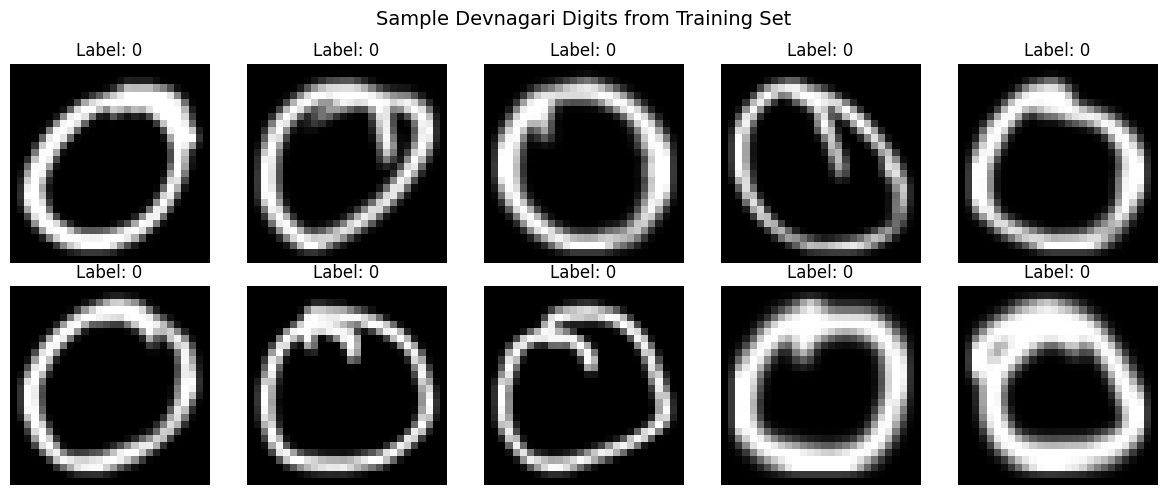

In [14]:
# Visualize sample images from the training set
plt.figure(figsize=(12, 5))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_train[i], cmap='gray')
    plt.title(f"Label: {y_train[i]}")
    plt.axis("off")
plt.suptitle("Sample Devnagari Digits from Training Set", fontsize=14)
plt.tight_layout()
plt.show()


## Task 2: Build the FCN Model

Creating a Sequential model with:
- Input: 784 features (flattened 28×28 images)
- Hidden Layer 1: 64 neurons, sigmoid activation
- Hidden Layer 2: 128 neurons, sigmoid activation
- Hidden Layer 3: 256 neurons, sigmoid activation
- Output Layer: 10 neurons, softmax activation


In [15]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input

# Build the Sequential FCN model
model = Sequential([
    Input(shape=(784,)),                          # Input layer: 784 features
    Dense(64, activation="sigmoid"),              # Hidden layer 1: 64 neurons
    Dense(128, activation="sigmoid"),             # Hidden layer 2: 128 neurons
    Dense(256, activation="sigmoid"),             # Hidden layer 3: 256 neurons
    Dense(10, activation="softmax"),              # Output layer: 10 classes
])

# Display model architecture
model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │        50,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 94,154 (367.79 KB)

 Trainable params: 94,154 (367.79 KB)

 Non-trainable params: 0 (0.00 B)

## Task 3: Compile the Model

Using:
- **Optimizer:** Adam (adaptive learning rate, works well for most tasks)
- **Loss:** Categorical Crossentropy (multi-class classification with one-hot encoded labels)
- **Metric:** Accuracy


In [16]:
# Compile the model
model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

print("Model compiled successfully.")


Model compiled successfully.


## Task 4: Train the Model

Training with:
- Batch size: 128
- Epochs: 20
- Validation split: 20%
- Callbacks: ModelCheckpoint and EarlyStopping


In [17]:
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

# Define callbacks
callbacks = [
    ModelCheckpoint(
        filepath="best_devnagari_model.keras",
        monitor="val_loss",
        save_best_only=True,
        verbose=1
    ),
    EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),
]

# Train the model
history = model.fit(
    x_train_flat,
    y_train_encoded,
    batch_size=128,
    epochs=20,
    validation_split=0.2,
    callbacks=callbacks,
    verbose=1
)


Epoch 1/20
103/107 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.2638 - loss: 1.9852
Epoch 1: val_loss improved from None to 7.22466, saving model to best_devnagari_model.keras

Epoch 1: finished saving model to best_devnagari_model.keras
107/107 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.4820 - loss: 1.6103 - val_accuracy: 0.0000e+00 - val_loss: 7.2247
Epoch 2/20
 99/107 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8188 - loss: 0.6321
Epoch 2: val_loss did not improve from 7.22466
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8561 - loss: 0.4967 - val_accuracy: 0.0000e+00 - val_loss: 8.6074
Epoch 3/20
104/107 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9101 - loss: 0.3051
Epoch 3: val_loss did not improve from 7.22466
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9224 - loss: 0.2715 - val_accuracy: 0.0000e+00 - val_loss: 9.2558
Epoch 4/20
105/107 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9433 - loss: 0.1985
Epoch 4: val_loss did not improve from 7.224

### Visualizing Training Progress

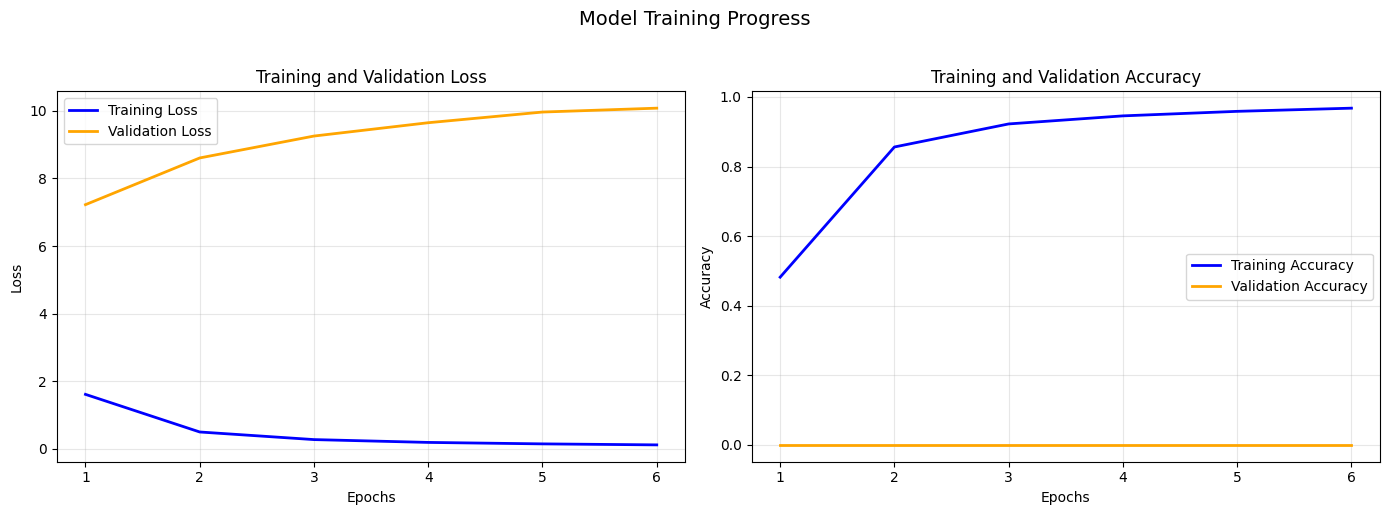

In [18]:
# Plot training and validation loss & accuracy
train_loss = history.history['loss']
val_loss = history.history['val_loss']
train_acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

epochs_range = range(1, len(train_loss) + 1)

plt.figure(figsize=(14, 5))

# Loss plot
plt.subplot(1, 2, 1)
plt.plot(epochs_range, train_loss, label='Training Loss', color='blue', linewidth=2)
plt.plot(epochs_range, val_loss, label='Validation Loss', color='orange', linewidth=2)
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.grid(True, alpha=0.3)

# Accuracy plot
plt.subplot(1, 2, 2)
plt.plot(epochs_range, train_acc, label='Training Accuracy', color='blue', linewidth=2)
plt.plot(epochs_range, val_acc, label='Validation Accuracy', color='orange', linewidth=2)
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()
plt.grid(True, alpha=0.3)

plt.suptitle('Model Training Progress', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()


## Task 5: Evaluate the Model

Evaluating on the test set to measure generalization performance.


In [19]:
# Evaluate the model on test data
test_loss, test_acc = model.evaluate(x_test_flat, y_test_encoded, verbose=2)

print(f"\n--- Test Results ---")
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")


94/94 - 0s - 2ms/step - accuracy: 0.6240 - loss: 2.0756

--- Test Results ---
Test Loss: 2.0756
Test Accuracy: 0.6240


## Task 6: Save and Load the Model

Saving the trained model to an `.h5` file and reloading it to verify.


In [20]:
# Save the model in H5 format
model.save('devnagari_fcn_model.h5')
print("Model saved as 'devnagari_fcn_model.h5'")

# Load the saved model
loaded_model = tf.keras.models.load_model('devnagari_fcn_model.h5')
print("Model loaded successfully.")

# Re-evaluate the loaded model to confirm it works correctly
loaded_loss, loaded_acc = loaded_model.evaluate(x_test_flat, y_test_encoded, verbose=2)
print(f"\n--- Loaded Model Test Results ---")
print(f"Test Loss: {loaded_loss:.4f}")
print(f"Test Accuracy: {loaded_acc:.4f}")


Model saved as 'devnagari_fcn_model.h5'
Model loaded successfully.
94/94 - 1s - 6ms/step - accuracy: 0.6240 - loss: 2.0756

--- Loaded Model Test Results ---
Test Loss: 2.0756
Test Accuracy: 0.6240


## Task 7: Predictions

Using the trained model to predict on test images and comparing with true labels.


In [21]:
# Make predictions on test data
predictions = model.predict(x_test_flat)

# Convert predicted probabilities to digit labels
predicted_labels = np.argmax(predictions, axis=1)
true_labels = np.argmax(y_test_encoded, axis=1)

# Display first 5 predictions
print("--- Sample Predictions ---")
for i in range(5):
    print(f"Image {i+1}: Predicted = {predicted_labels[i]}, True = {true_labels[i]}, "
          f"{'✓ Correct' if predicted_labels[i] == true_labels[i] else '✗ Wrong'}")


94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
--- Sample Predictions ---
Image 1: Predicted = 0, True = 0, ✓ Correct
Image 2: Predicted = 0, True = 0, ✓ Correct
Image 3: Predicted = 0, True = 0, ✓ Correct
Image 4: Predicted = 0, True = 0, ✓ Correct
Image 5: Predicted = 0, True = 0, ✓ Correct


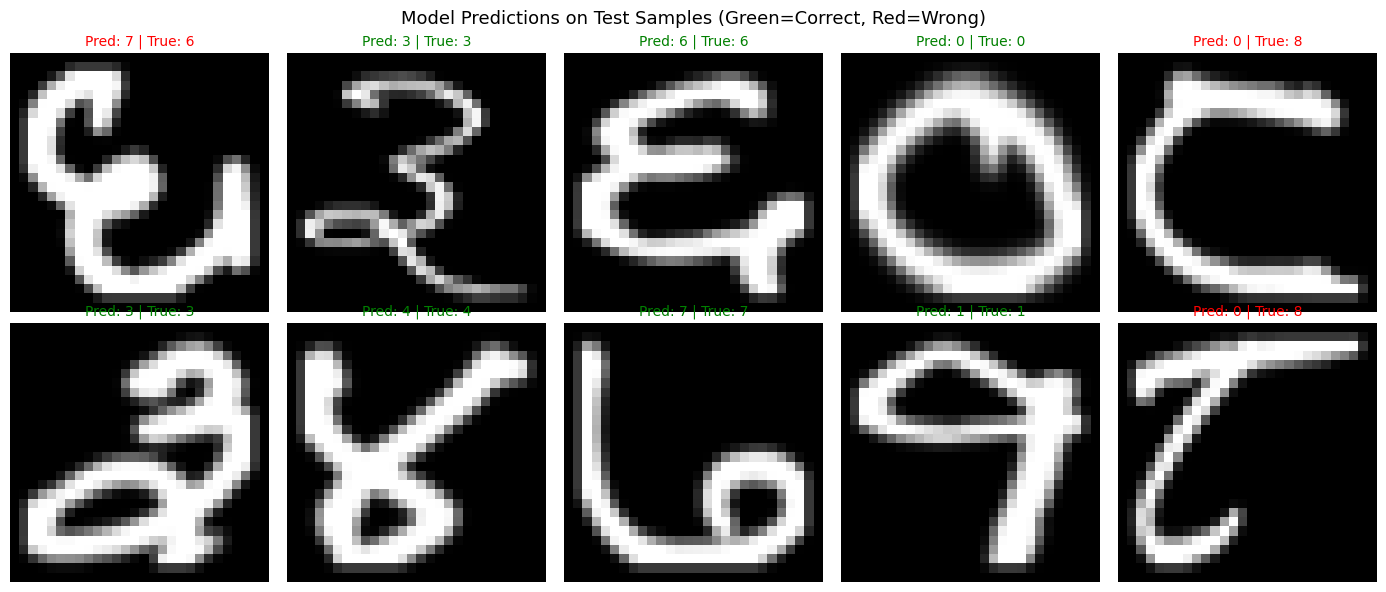

In [22]:
# Visualize predictions on sample test images
plt.figure(figsize=(14, 6))
# Pick 10 random test samples
np.random.seed(42)
sample_indices = np.random.choice(len(x_test), 10, replace=False)

for i, idx in enumerate(sample_indices):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_test[idx], cmap='gray')

    pred = predicted_labels[idx]
    true = true_labels[idx]
    color = 'green' if pred == true else 'red'

    plt.title(f"Pred: {pred} | True: {true}", color=color, fontsize=10)
    plt.axis("off")

plt.suptitle("Model Predictions on Test Samples (Green=Correct, Red=Wrong)", fontsize=13)
plt.tight_layout()
plt.show()


In [23]:
# Print overall prediction statistics
correct = np.sum(predicted_labels == true_labels)
total = len(true_labels)
print(f"\n--- Prediction Summary ---")
print(f"Correct predictions: {correct}/{total}")
print(f"Overall accuracy: {correct/total:.4f}")

# Per-class accuracy
print(f"\n--- Per-Class Accuracy ---")
for digit in range(10):
    mask = true_labels == digit
    class_correct = np.sum(predicted_labels[mask] == true_labels[mask])
    class_total = np.sum(mask)
    if class_total > 0:
        print(f"Digit {digit}: {class_correct}/{class_total} = {class_correct/class_total:.4f}")



--- Prediction Summary ---
Correct predictions: 1872/3000
Overall accuracy: 0.6240

--- Per-Class Accuracy ---
Digit 0: 292/300 = 0.9733
Digit 1: 290/300 = 0.9667
Digit 2: 14/300 = 0.0467
Digit 3: 254/300 = 0.8467
Digit 4: 285/300 = 0.9500
Digit 5: 249/300 = 0.8300
Digit 6: 227/300 = 0.7567
Digit 7: 261/300 = 0.8700
Digit 8: 0/300 = 0.0000
Digit 9: 0/300 = 0.0000


---
## Summary

This notebook completed all 7 tasks of the Worksheet 4 exercise:

1. **Data Preparation** — Loaded Devnagari digit images using PIL, normalized to [0,1], and one-hot encoded labels.
2. **Model Building** — Created a Sequential FCN with 3 hidden layers (64→128→256 neurons, sigmoid activation) and a softmax output layer.
3. **Compilation** — Compiled with Adam optimizer, categorical crossentropy loss, and accuracy metric.
4. **Training** — Trained for 20 epochs with batch size 128, 20% validation split, and ModelCheckpoint/EarlyStopping callbacks.
5. **Evaluation** — Evaluated test accuracy and loss using `model.evaluate()`.
6. **Save/Load** — Saved to `.h5` file and reloaded to verify performance.
7. **Predictions** — Generated predictions using `model.predict()`, visualized results, and computed per-class accuracy.
